# Промышленность

## Описание


### Описание проекта.
Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Ваша задача — построить модель, которая будет её предсказывать. Заказчик хочет использовать разработанную модель для имитации технологического процесса. Изучите его, прежде чем генерировать новые признаки.



### Описание процесса обработки
Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн. Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом. Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены на крышке ковша.
Сначала происходит десульфурация — из стали выводят серу и корректируют её химический состав добавлением примесей. Затем сталь легируют — добавляют в неё куски сплава из бункера для сыпучих материалов или порошковую проволоку через специальный трайб-аппарат.
Прежде чем в первый раз ввести легирующие добавки, специалисты производят химический анализ стали и измеряют её температуру. Потом температуру на несколько минут повышают, уже после этого добавляют легирующие материалы и продувают сталь инертным газом, чтобы перемешать, а затем снова проводят измерения. Такой цикл повторяется до тех пор, пока не будут достигнуты нужный химический состав стали и оптимальная температура плавки.
Дальше расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки. Оттуда готовый продукт выходит в виде заготовок-слябов (англ. slab, «плита»).


### Описание данных
Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом. Она состоит из нескольких таблиц:

steel.data_arc — данные об электродах;

steel.data_bulk — данные об объёме сыпучих материалов;

steel.data_bulk_time — данные о времени подачи сыпучих материалов;

steel.data_gas — данные о продувке сплава газом;

steel.data_temp — данные об измерениях температуры;

steel.data_wire — данные об объёме проволочных материалов;

steel.data_wire_time — данные о времени подачи проволочных материалов.

Таблица steel.data_arc
key — номер партии;
BeginHeat — время начала нагрева;
EndHeat — время окончания нагрева;
ActivePower — значение активной мощности;
ReactivePower — значение реактивной мощности.
Таблица steel.data_bulk
key — номер партии;
Bulk1 … Bulk15 — объём подаваемого материала.
Таблица steel.data_bulk_time
key — номер партии;
Bulk1 … Bulk15 — время подачи материала.
Таблица steel.data_gas
key — номер партии;
gas — объём подаваемого газа.
Таблица steel.data_temp
key — номер партии;
MesaureTime — время замера;
Temperature — значение температуры.
Таблица steel.data_wire
key — номер партии;
Wire1 … Wire9 — объём подаваемых проволочных материалов.
Таблица steel.data_wire_time
key — номер партии;
Wire1 … Wire9 — время подачи проволочных материалов.
Во всех файлах столбец key содержит номер партии. В таблицах может быть несколько строк с одинаковым значением key: они соответствуют разным итерациям обработки.

## Инструкция по выполнению проекта

### Шаг 1. Загрузите данные
В начале работы над проектом подключитесь к базе данных в Sqlite. Для этого достаточно иметь доступ к файлу с расширением .db.
Чтобы его загрузить, используйте команду wget в отдельной ячейке Jupiter Notebook:

!wget https://code.s3.yandex.net/data-scientist/ds-plus-final.db 
Этот способ подойдёт для выполнения проекта на платформе Практикума. Если вы планируете работать локально, то можете скачать файл, перейдя по ссылке.
Далее для подключения к базе данных используйте этот код:

import os
import pandas as pd
from sqlalchemy import create_engine

path_to_db = 'ds-plus-final.db'
engine = create_engine(f'sqlite:///{path_to_db}', echo=False) 
При выполнении проекта задайте константу RANDOM_STATE. Её значение будет равно дате начала вашей работы над проектом. Например, если это 1 сентября 2022 года, то RANDOM_STATE = 10922. Используйте эту константу везде, где это необходимо: например при разделении данных на выборки.

### Шаг 2. Проведите исследовательский анализ и предобработку данных
Проанализируйте исходные данные. Проверьте:
Все ли таблицы содержат данные.
Соответствует ли количество таблиц условию задачи.
Для таблицы steel.data_arc:
Проведите исследовательский анализ данных: проверьте наличие пропусков и аномалий, изучите распределение признаков.
Вам нужно либо удалить всю партию с аномальным значением, либо заменить аномальное значение, основываясь на нормальных наблюдениях.
Попробуйте сгенерировать новые признаки, которые могут пригодиться при обучении: длительность нагрева, общую мощность, соотношение активной мощности к реактивной, количество запуска нагрева электродами и другие.
При агрегировании наблюдений по ключу учитывайте порядок арифметических действий: сначала сгенерируйте новые признаки, затем уже агрегируйте наблюдения.
Для таблицы steel.data_bulk:
Проведите исследовательский анализ данных: проверьте наличие пропусков и аномалий, изучите распределение признаков.
Обработайте пропуски. Пропуск означает, что материал не добавляли в партию.
Для таблицы steel.data_bulk_time:
Проведите исследовательский анализ данных: проверьте наличие пропусков и аномалий, изучите распределение признаков.
Проверьте данные на адекватность: например, убедитесь, что подача материала не измеряется сутками. Обратите внимание: перед вами не стоит задача временных рядов.
Для таблицы steel.data_gas:
Проведите исследовательский анализ данных: проверьте наличие пропусков и аномалий, изучите распределение признаков.
Для таблицы steel.data_temp:
Проведите исследовательский анализ данных: проверьте наличие пропусков и аномалий, изучите распределения признаков.
Целевой признак — последняя температура партии. Начальную температуру партии можно использовать как входной признак. Любые другие промежуточные значения температуры приведут к утечке целевого признака, их нельзя использовать как входные.
При агрегировании наблюдений используйте только ключи, у которых как минимум два наблюдения: первый и последний замеры температуры.
Заказчик предупредил, что значения температуры ниже 1500 градусов — аномальные.
Для таблицы steel.data_wire:
Обработайте пропуски. Пропуск означает, что материал не добавляли в эту партию.
Для таблицы steel.data_wire_time:
Проведите исследовательский анализ данных: проверьте наличие пропусков и аномалий, изучите распределение признаков.
Проверьте данные на адекватность: например, убедитесь, что подача материала не измеряется сутками. Обратите внимание: перед вами не стоит задача временных рядов.
Объедините таблицы по ключу:
Каждой партии должно соответствовать одно наблюдение.
Учтите: во все партии точно добавлялись сыпучие и проволочные материалы, везде была выполнена продувка газом и сплав всегда нагревался.
Заказчик предупредил, что иногда наблюдается асинхронность в заданном времени разных датчиков. Если вы будете выстраивать хронологию процессов для разных партий, то можете столкнуться с тем, что полученная хронология не соответствует хронологии в описании. Не стоит воспринимать это как ошибку.
Проведите исследовательский анализ данных объединённой таблицы и визуализируйте распределение каждого признака, напишите выводы.
Проведите корреляционный анализ.
Подготовьте данные для обучения:
Выберите признаки, которые будете использовать для обучения, учитывайте особенности данных и выбранных моделей.
Разделите данные на тренировочную и тестовую выборки (test_size = 0.25).
Подготовьте выборки для обучения, учитывайте особенности выбранных моделей.


### Шаг 3. Обучите модель
Рассмотрите классы моделей:
решающее дерево или случайный лес,
бустинги,
нейронные сети.
Найдите лучшую модель для прогноза последней измеренной температуры. Оцените её качество метрикой MAE. Выберите лучшую модель по значению метрики на кросс-валидации.
Подберите значения как минимум двум гиперпараметрам хотя бы для одной модели. Лучше всего использовать методы автоматизированного подбора гиперпараметров: GridSearchCV, RandomizedSearchCV, OptunaSearchCV, Optuna и другие.


### Шаг 4. Протестируйте модель и продемонстрируйте её работу
Проверьте качество лучшей модели на тестовой выборке. Значение метрики MAE должно быть менее 6.8.
Дополнительно можете оценить R².
Сравните результаты лучшей и константной моделей.
Проанализируйте важность основных признаков.
Для одного из важных признаков проведите дополнительное исследование:
Покажите график зависимости входного и целевого признаков.


### Шаг 5. Сделайте общий вывод по работе
Напишите общие выводы, предложите способы для дальнейшего улучшения модели и дайте бизнес-рекомендации заказчику.

## Загрузка данных

In [1]:
!wget https://code.s3.yandex.net/data-scientist/ds-plus-final.db


!pip install lightgbm
!pip install xgboost

"wget" ­Ґ пў«пҐвбп ў­гваҐ­­Ґ© Ё«Ё ў­Ґи­Ґ©
Є®¬ ­¤®©, ЁбЇ®«­пҐ¬®© Їа®Ја ¬¬®© Ё«Ё Ї ЄҐв­л¬ д ©«®¬.


In [2]:
RANDOM_STATE = 51125 #5 октября 2025 года

##

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sqlalchemy import create_engine #это и блок код ниже не понадобится, если сработал код выше

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [4]:
path_to_db = 'ds-plus-final.db'
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

engine = C:\Users\Neria\Desktop\final

## Исследовательский анализ данных

Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом. Она состоит из нескольких таблиц:
steel.data_arc — данные об электродах;
steel.data_bulk — данные об объёме сыпучих материалов;
steel.data_bulk_time — данные о времени подачи сыпучих материалов;
steel.data_gas — данные о продувке сплава газом;
steel.data_temp — данные об измерениях температуры;
steel.data_wire — данные об объёме проволочных материалов;
steel.data_wire_time — данные о времени подачи проволочных материалов.

### Проверка количества таблииц и их столбцов.

In [5]:
tables = [
    'data_arc',
    'data_bulk', 
    'data_bulk_time',
    'data_gas',
    'data_temp',
    'data_wire',
    'data_wire_time'
]

overview_data = []

with engine.connect() as conn:
    existing_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

for table in tables:
    df = pd.read_sql_table(table, engine)
    overview_data.append({
        'Таблица': table,
        'Строк': len(df),
        'Столбцов': df.shape[1]
    })
    
overview = pd.DataFrame(overview_data)

In [6]:
display(overview)

,Таблица,Строк,Столбцов
0,data_arc,14876,5
1,data_bulk,3129,16
2,data_bulk_time,3129,16
3,data_gas,3239,2
4,data_temp,18092,3
5,data_wire,3081,10
6,data_wire_time,3081,10


Они есть. Нам действительно придется рассмотреть 7 таблиц. На данный момент, количество столбцов полностью соответствует содержанию.

А если их все по ключу объединять, то получится очень большая таблица, которую будет трудно визуализировать. Да и для обучения модели обычно годится лишь несколько признаков.

Итого: Задачf и бизнес-идея ясны.
Подключение к базам данных прошло успешно. Если возникли проблемы с этим на вашем устройстве, то скачайте это:

 https://code.s3.yandex.net/data-scientist/ds-plus-final.db 

Таблицы отличаются по формату и размеру.(от 3081 до 18092)

data_temp - огромная таблица (18092 строк)
data_bulk и data_bulk_time имеют одинаковое количество строк (3129), как и data_wire с data_wire_time (3081). Прекрасно.


Для начала, рассмотрим для этого все таблицы через функцию ниже. Отдельное внимание будет для общего ключа и целевого признака.

### Проверка названий столбцов и их содержания.

In [7]:
def check_table_content(engine, table_name):
    query = f'''
    SELECT *
    FROM {table_name}
    LIMIT 10;
    '''
    return pd.read_sql_query(query, con=engine)

#### Проверка data_arc

Таблица steel.data_arc
key — номер партии;
BeginHeat — время начала нагрева;
EndHeat — время окончания нагрева;
ActivePower — значение активной мощности;
ReactivePower — значение реактивной мощности.

In [8]:
display(check_table_content(engine, 'data_arc'))

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691
5,2,2019-05-03 11:34:14,2019-05-03 11:36:31,0.381124,0.220351
6,2,2019-05-03 11:38:50,2019-05-03 11:44:28,0.261665,0.205527
7,2,2019-05-03 11:46:19,2019-05-03 11:48:25,0.710297,0.484962
8,2,2019-05-03 11:49:48,2019-05-03 11:53:18,0.786322,0.542517
9,3,2019-05-03 12:06:54,2019-05-03 12:11:34,1.101678,0.820856


Формат даты надо бы подправить. То есть, перевести его в минуты. И мощность надо поменять.

#### Проверка data_bulk


Таблица steel.data_bulk
key — номер партии;
Bulk1 … Bulk15 — объём подаваемого материала.


In [9]:
display(check_table_content(engine, 'data_bulk'))

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,None,None,None,43.0,None,None,None,None,None,None,None,206.0,None,150.0,154.0
1,2,None,None,None,73.0,None,None,None,None,None,None,None,206.0,None,149.0,154.0
2,3,None,None,None,34.0,None,None,None,None,None,None,None,205.0,None,152.0,153.0
3,4,None,None,None,81.0,None,None,None,None,None,None,None,207.0,None,153.0,154.0
4,5,None,None,None,78.0,None,None,None,None,None,None,None,203.0,None,151.0,152.0
5,6,None,None,None,117.0,None,None,None,None,None,None,None,204.0,None,201.0,154.0
6,7,None,None,None,117.0,None,None,None,None,None,None,None,204.0,None,152.0,154.0
7,8,None,None,None,99.0,None,None,None,None,None,None,None,410.0,None,252.0,153.0
8,9,None,None,None,117.0,None,None,None,None,None,None,None,107.0,None,99.0,203.0
9,10,None,None,None,NaN,None,None,None,None,None,None,None,203.0,None,102.0,204.0


Много пропусков. Данные повреждены? Нет. На этих этапах ничего не подавалось. В описании указано об этом.

"Пропуск означает, что материал не добавляли в партию." Заменю на ноль в будущем


#### Проверка data_bulk_time
Таблица steel.data_bulk_time
key — номер партии;
Bulk1 … Bulk15 — время подачи материала.


In [10]:
display(check_table_content(engine, 'data_bulk_time'))

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,None,None,None,2019-05-03 11:28:48,None,None,None,None,None,None,None,2019-05-03 11:24:31,None,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,None,2019-05-03 11:36:50,None,None,None,None,None,None,None,2019-05-03 11:53:30,None,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,None,2019-05-03 12:32:39,None,None,None,None,None,None,None,2019-05-03 12:27:13,None,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,None,None,None,2019-05-03 12:43:22,None,None,None,None,None,None,None,2019-05-03 12:58:00,None,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,None,None,None,2019-05-03 13:30:47,None,None,None,None,None,None,None,2019-05-03 13:30:47,None,2019-05-03 13:34:12,2019-05-03 13:30:47
5,6,None,None,None,2019-05-03 13:57:27,None,None,None,None,None,None,None,2019-05-03 13:48:52,None,2019-05-03 14:09:42,2019-05-03 14:03:15
6,7,None,None,None,2019-05-03 14:18:58,None,None,None,None,None,None,None,2019-05-03 14:41:26,None,2019-05-03 14:30:50,2019-05-03 14:27:16
7,8,None,None,None,2019-05-03 15:17:58,None,None,None,None,None,None,None,2019-05-03 15:17:58,None,2019-05-03 15:13:18,2019-05-03 15:05:33
8,9,None,None,None,2019-05-03 16:03:08,None,None,None,None,None,None,None,2019-05-03 16:03:08,None,2019-05-03 16:00:16,2019-05-03 15:52:39
9,10,None,None,None,None,None,None,None,None,None,None,None,2019-05-03 16:38:11,None,2019-05-03 16:34:24,2019-05-03 16:29:56


Время - аналогично

#### Проверка data_gas


Таблица steel.data_gas
key — номер партии;
gas — объём подаваемого газа.

In [11]:
display(check_table_content(engine, 'data_gas'))

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692
5,6,11.273392
6,7,9.836267
7,8,15.171553
8,9,8.216623
9,10,6.529891


Ничего примечательного

#### Проверка data_temp


Таблица steel.data_temp
key — номер партии;
MesaureTime — время замера;
Temperature — значение температуры.


In [12]:
display(check_table_content(engine, 'data_temp'))

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0
5,1,2019-05-03 11:30:38,1613.0
6,2,2019-05-03 11:34:04,1581.0
7,2,2019-05-03 11:38:40,1577.0
8,2,2019-05-03 11:46:09,1589.0
9,2,2019-05-03 11:49:38,1604.0


#### Проверка data_wire

Таблица steel.data_wire
key — номер партии;
Wire1 … Wire9 — объём подаваемых проволочных материалов.


In [13]:
display(check_table_content(engine, 'data_wire'))

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,None,None,None,None,None,None,None,None
1,2,96.052315,None,None,None,None,None,None,None,None
2,3,91.160157,None,None,None,None,None,None,None,None
3,4,89.063515,None,None,None,None,None,None,None,None
4,5,89.238236,9.11456,None,None,None,None,None,None,None
5,6,99.109917,9.11456,None,None,None,None,None,None,None
6,7,98.061600,None,None,None,None,None,None,None,None
7,8,155.282394,None,None,None,None,None,None,None,None
8,9,113.393279,9.143681,None,None,None,None,None,None,None
9,10,81.244796,12.376,None,None,None,None,None,None,None


Аналогично с другим материалом. 

#### Проверка data_wire_time


Таблица steel.data_wire_time
key — номер партии;
Wire1 … Wire9 — время подачи проволочных материалов.


In [14]:
display(check_table_content(engine, 'data_wire_time'))

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,None,None,None,None,None,None,None,None
1,2,2019-05-03 11:36:50,None,None,None,None,None,None,None,None
2,3,2019-05-03 12:11:46,None,None,None,None,None,None,None,None
3,4,2019-05-03 12:43:22,None,None,None,None,None,None,None,None
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,None,None,None,None,None,None,None
5,6,2019-05-03 13:57:27,2019-05-03 13:48:52,None,None,None,None,None,None,None
6,7,2019-05-03 14:18:58,None,None,None,None,None,None,None,None
7,8,2019-05-03 15:01:30,None,None,None,None,None,None,None,None
8,9,2019-05-03 15:45:44,2019-05-03 15:39:37,None,None,None,None,None,None,None
9,10,2019-05-03 16:27:00,2019-05-03 16:22:36,None,None,None,None,None,None,None


Во всех файлах столбец key содержит номер партии. В таблицах может быть несколько строк с одинаковым значением key: они соответствуют разным итерациям обработки.

data_arc (электроды): Множественные записи на одну партию (несколько циклов нагрева)
Временные метки в формате datetime
Активная и реактивная мощность - числовые значения

data_bulk и data_bulk_time (сыпучие материалы):
Сильная разреженность - в основном используются только Bulk 4, 12, 14, 15
Много пропусков (None/NaN)
Временные метки показывают последовательность операций

data_gas (газ):
Одна запись на партию
Объем газа - числовое значение

data_temp (температура):
Множественные замеры температуры для каждой партии
Целевая переменная для модели

data_wire и data_wire_time (проволочные материалы):
В основном используются Wire 1 и иногда Wire 2



1) Убрать в bulk и wire таблицах пропуски.
2) Сделать время понятным для себя и модели
3) Абсолютно точно буду добавлять новые признаки. Это логичное действие по нескольким причинам:
 
     3.1) Можно извлечь признаки из других признаков.

     3.2) Для целевого признака кореляция будет высокой лишь для нескольких. Важно рассмотреть все возможные варианты с учетом того, что некоторые данные явно не нужны, но с их помощью можно получить новые данные, которые могут оказаться уже нужными. Заранее сказать нельзя.
 
     3.3) Специфика проекта. Это физика. А в ней важны наблюдения. С учетом некой ограниченности и отсутствия некоторых данных, которые могли бы так же помочь, мне придется их выжимать самому.
 
4) Обьединить их(как данность)


### Предобработка данных

В SQL работать не удобнее. Переведу все данные в соответствующие датафреймы.

К сожалению, единую функцию для обработки всех данных не создать.

#### Для таблицы steel.data_arc:

Вам нужно либо удалить всю партию с аномальным значением, либо заменить аномальное значение, основываясь на нормальных наблюдениях.
Попробуйте сгенерировать новые признаки, которые могут пригодиться при обучении: длительность нагрева, общую мощность, соотношение активной мощности к реактивной, количество запуска нагрева электродами и другие.
При агрегировании наблюдений по ключу учитывайте порядок арифметических действий: сначала сгенерируйте новые признаки, затем уже агрегируйте наблюдения.

По заданию:
Создам 'длительность_нагрева', 'общая_мощность', 'отношение_мощностей'


In [15]:
data_arc = pd.read_sql_query('SELECT * FROM data_arc', con=engine)

data_arc['Начало нагрева дугой'] = pd.to_datetime(data_arc['Начало нагрева дугой'])
data_arc['Конец нагрева дугой'] = pd.to_datetime(data_arc['Конец нагрева дугой'])

data_arc['длительность_нагрева'] = (data_arc['Конец нагрева дугой'] - data_arc['Начало нагрева дугой']).dt.total_seconds()
data_arc['полная_мощность'] = (data_arc['Активная мощность'] ** 2 + data_arc['Реактивная мощность'] ** 2) ** 0.5
data_arc['отношение_мощностей'] = data_arc['Активная мощность'] / data_arc['Реактивная мощность']

Потом агрегация

In [16]:
arc_features = data_arc.groupby('key').agg({
    'длительность_нагрева': ['sum', 'mean', 'count'],
    'Активная мощность': ['mean', 'max', 'min'],
    'Реактивная мощность': ['mean', 'max', 'min'], 
    'полная_мощность': ['mean', 'sum', 'max'],
    'отношение_мощностей': ['mean', 'std']
}).round(4)


arc_features.columns = ['_'.join(col).strip() for col in arc_features.columns]
arc_features = arc_features.reset_index().rename(columns={
    'длительность_нагрева_count': 'количество_запусков_нагрева', # в будущем не будет понятно что значит sum, mean итд, а потому переименую
    'длительность_нагрева_sum': 'общее_время_нагрева',
    'длительность_нагрева_mean': 'средняя_длительность_нагрева'
})

arc_features['отношение_мощностей_std'] = arc_features['отношение_мощностей_std'].fillna(0)

invalid_keys = data_arc[(data_arc['Активная мощность'] <= 0) | (data_arc['Реактивная мощность'] <= 0)]['key'].unique() #отрицательной мощности нет
data_arc = arc_features[~arc_features['key'].isin(invalid_keys)]

In [17]:
display(data_arc.head())

,key,общее_время_нагрева,средняя_длительность_нагрева,количество_запусков_нагрева,Активная мощность_mean,Активная мощность_max,Активная мощность_min,Реактивная мощность_mean,Реактивная мощность_max,Реактивная мощность_min,полная_мощность_mean,полная_мощность_sum,полная_мощность_max,отношение_мощностей_mean,отношение_мощностей_std
0,1,1098.0,219.60,5,0.6073,0.8671,0.3051,0.4286,0.6437,0.2113,0.7437,3.7187,1.0799,1.4216,0.1094
1,2,811.0,202.75,4,0.5349,0.7863,0.2617,0.3633,0.5425,0.2055,0.6471,2.5883,0.9553,1.4792,0.1882
2,3,655.0,131.00,5,0.8127,1.2230,0.4217,0.5875,0.8637,0.2726,1.0038,5.0192,1.4972,1.3961,0.1647
3,4,741.0,185.25,4,0.6766,0.8879,0.3107,0.5142,0.6547,0.2418,0.8500,3.4000,1.0971,1.3074,0.0560
4,5,869.0,217.25,4,0.5632,0.8930,0.3246,0.4220,0.6608,0.2791,0.7042,2.8170,1.1109,1.3289,0.1371


In [18]:
data_arc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3213 entries, 0 to 3213
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   key                           3213 non-null   int64  
 1   общее_время_нагрева           3213 non-null   float64
 2   средняя_длительность_нагрева  3213 non-null   float64
 3   количество_запусков_нагрева   3213 non-null   int64  
 4   Активная мощность_mean        3213 non-null   float64
 5   Активная мощность_max         3213 non-null   float64
 6   Активная мощность_min         3213 non-null   float64
 7   Реактивная мощность_mean      3213 non-null   float64
 8   Реактивная мощность_max       3213 non-null   float64
 9   Реактивная мощность_min       3213 non-null   float64
 10  полная_мощность_mean          3213 non-null   float64
 11  полная_мощность_sum           3213 non-null   float64
 12  полная_мощность_max           3213 non-null   float64
 13  отношени

In [19]:
data_arc.describe()

,key,общее_время_нагрева,средняя_длительность_нагрева,количество_запусков_нагрева,Активная мощность_mean,Активная мощность_max,Активная мощность_min,Реактивная мощность_mean,Реактивная мощность_max,Реактивная мощность_min,полная_мощность_mean,полная_мощность_sum,полная_мощность_max,отношение_мощностей_mean,отношение_мощностей_std
count,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000,3213.000000
mean,1622.907874,794.691566,172.359237,4.628696,0.661332,0.961756,0.420055,0.485966,0.715411,0.304161,0.821564,3.811200,1.197216,1.373774,0.120589
std,934.844882,332.439136,45.599742,1.608860,0.128391,0.231503,0.118570,0.097600,0.184338,0.088231,0.160134,1.502848,0.291135,0.066172,0.049058
min,1.000000,57.000000,57.000000,1.000000,0.267700,0.267700,0.223100,0.196200,0.196200,0.153800,0.331900,0.331900,0.331900,1.099600,0.000000
25%,817.000000,571.000000,140.000000,4.000000,0.573000,0.797200,0.331600,0.417400,0.584600,0.239500,0.711200,2.775600,0.990200,1.331100,0.087400
50%,1623.000000,770.000000,168.750000,4.000000,0.652900,0.967200,0.405600,0.481600,0.710900,0.291300,0.812400,3.694500,1.199500,1.374300,0.120100
75%,2432.000000,983.000000,200.400000,6.000000,0.739400,1.149000,0.478700,0.543300,0.847500,0.348300,0.916600,4.697400,1.426400,1.418200,0.153400
max,3241.000000,4189.000000,380.000000,16.000000,1.243900,1.463800,1.140700,0.960800,1.270300,0.875900,1.572200,15.288300,1.898200,1.663400,0.356600


#### Для таблицы steel.data_bulk:

Обработайте пропуски. Пропуск означает, что материал не добавляли в партию.


In [20]:
data_bulk = pd.read_sql_query('SELECT * FROM data_bulk', con=engine)
bulk_columns = [f'Bulk {i}' for i in range(1, 16)]


data_bulk[bulk_columns] = data_bulk[bulk_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

data_bulk['общий_объем_сыпучих'] = data_bulk[bulk_columns].sum(axis=1)
data_bulk['количество_типов_сыпучих'] = (data_bulk[bulk_columns] > 0).sum(axis=1)
data_bulk['максимальная_порция'] = data_bulk[bulk_columns].max(axis=1)
data_bulk['минимальная_порция'] = data_bulk[bulk_columns].replace(0, np.nan).min(axis=1).fillna(0)
data_bulk['средняя_порция'] = data_bulk[bulk_columns].replace(0, np.nan).mean(axis=1).fillna(0)

In [21]:
q95 = data_bulk['общий_объем_сыпучих'].quantile(0.95)
data_bulk['высокий_объем_сыпучих'] = (data_bulk['общий_объем_сыпучих'] > q95).astype(int)

data_bulk = data_bulk[['key'] + [col for col in data_bulk.columns if col not in bulk_columns + ['key']]]

In [22]:
display(data_bulk.head())

,key,общий_объем_сыпучих,количество_типов_сыпучих,максимальная_порция,минимальная_порция,средняя_порция,высокий_объем_сыпучих
0,1,553.0,4,206.0,43.0,138.25,0
1,2,582.0,4,206.0,73.0,145.50,0
2,3,544.0,4,205.0,34.0,136.00,0
3,4,595.0,4,207.0,81.0,148.75,0
4,5,584.0,4,203.0,78.0,146.00,0


In [23]:
data_bulk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   key                       3129 non-null   int64  
 1   общий_объем_сыпучих       3129 non-null   float64
 2   количество_типов_сыпучих  3129 non-null   int64  
 3   максимальная_порция       3129 non-null   float64
 4   минимальная_порция        3129 non-null   float64
 5   средняя_порция            3129 non-null   float64
 6   высокий_объем_сыпучих     3129 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 171.2 KB


In [24]:
data_bulk.describe()

,key,общий_объем_сыпучих,количество_типов_сыпучих,максимальная_порция,минимальная_порция,средняя_порция,высокий_объем_сыпучих
count,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000
mean,1624.383509,595.503356,3.566315,255.058166,89.567913,163.792726,0.049856
std,933.337642,276.557794,1.216165,115.717918,48.218750,53.755069,0.217683
min,1.000000,19.000000,1.000000,19.000000,1.000000,19.000000,0.000000
25%,816.000000,429.000000,3.000000,202.000000,53.000000,129.000000,0.000000
50%,1622.000000,591.000000,4.000000,216.000000,91.000000,155.000000,0.000000
75%,2431.000000,772.000000,4.000000,309.000000,108.000000,195.500000,0.000000
max,3241.000000,3235.000000,7.000000,1849.000000,412.000000,539.166667,1.000000


#### Для таблицы steel.data_bulk_time:
Проверьте данные на адекватность: например, убедитесь, что подача материала не измеряется сутками. Обратите внимание: перед вами не стоит задача временных рядов.


In [25]:
data_bulk_time = pd.read_sql_query('SELECT * FROM data_bulk_time', con=engine)
bulk_time_columns = [f'Bulk {i}' for i in range(1, 16)]

time_features = []
for idx, row in data_bulk_time.iterrows():
    key = row['key']
    times = [pd.to_datetime(row[col]) for col in bulk_time_columns 
            if pd.notna(row[col]) and str(row[col]) != 'None' and str(row[col]) != 'nan']
    
    time_feature = {'key': key, 'количество_подач': len(times)}
    
    if len(times) > 1:
        times_sorted = sorted(times)
        time_range = (max(times_sorted) - min(times_sorted)).total_seconds() / 60
        intervals = [(times_sorted[i+1] - times_sorted[i]).total_seconds() / 60 
                    for i in range(len(times_sorted)-1)]
        
        time_feature.update({
            'общее_время_подач_мин': time_range,
            'максимальный_интервал_мин': max(intervals),
            'минимальный_интервал_мин': min(intervals),
            'средний_интервал_мин': np.mean(intervals)
        })
    else:
        time_feature.update({
            'общее_время_подач_мин': 0,
            'максимальный_интервал_мин': 0,
            'минимальный_интервал_мин': 0,
            'средний_интервал_мин': 0
        })
    
    time_features.append(time_feature)

data_bulk_time = pd.DataFrame(time_features)

In [26]:
display(data_bulk_time.head())

,key,количество_подач,общее_время_подач_мин,максимальный_интервал_мин,минимальный_интервал_мин,средний_интервал_мин
0,1,4,18.083333,9.683333,4.116667,6.027778
1,2,4,16.666667,7.816667,3.966667,5.555556
2,3,4,16.383333,6.200000,4.750000,5.461111
3,4,4,14.633333,6.816667,3.233333,4.877778
4,5,4,3.416667,3.416667,0.000000,1.138889


In [27]:
data_bulk_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   key                        3129 non-null   int64  
 1   количество_подач           3129 non-null   int64  
 2   общее_время_подач_мин      3129 non-null   float64
 3   максимальный_интервал_мин  3129 non-null   float64
 4   минимальный_интервал_мин   3129 non-null   float64
 5   средний_интервал_мин       3129 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 146.8 KB


In [28]:
data_bulk_time.describe()

,key,количество_подач,общее_время_подач_мин,максимальный_интервал_мин,минимальный_интервал_мин,средний_интервал_мин
count,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000
mean,1624.383509,3.566315,16.081778,9.503420,2.630596,5.695023
std,933.337642,1.216165,13.301467,8.706211,3.201952,4.048694
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,816.000000,3.000000,8.083333,5.483333,0.000000,3.483333
50%,1622.000000,4.000000,14.616667,7.883333,2.450000,5.216667
75%,2431.000000,4.000000,21.850000,12.216667,4.450000,7.433333
max,3241.000000,7.000000,228.050000,211.183333,36.683333,57.012500


#### Для таблицы steel.data_gas:


In [29]:
data_gas = pd.read_sql_query('SELECT * FROM data_gas', con=engine)
data_gas = data_gas.rename(columns={'Газ 1': 'объем_газа'})

In [30]:
display(data_gas.head())

,key,объем_газа
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [31]:
data_gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   key         3239 non-null   int64  
 1   объем_газа  3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


In [32]:
data_gas.describe()

,key,объем_газа
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


Это м^3?

#### Для таблицы steel.data_temp:
Целевой признак — последняя температура партии. Начальную температуру партии можно использовать как входной признак. Любые другие промежуточные значения температуры приведут к утечке целевого признака, их нельзя использовать как входные.
При агрегировании наблюдений используйте только ключи, у которых как минимум два наблюдения: первый и последний замеры температуры.
Заказчик предупредил, что значения температуры ниже 1500 градусов — аномальные.

In [33]:
data_temp = pd.read_sql_query('SELECT * FROM data_temp', con=engine)
data_temp['Время замера'] = pd.to_datetime(data_temp['Время замера'])
data_temp['Температура'] = pd.to_numeric(data_temp['Температура'], errors='coerce')

data_temp = data_temp[(data_temp['Температура'] >= 1500) & (data_temp['Температура'] <= 1700)]   # Ну, аномальные, так аномальные.
data_temp = data_temp.dropna(subset=['Температура'])

temp_features = []
for key, group in data_temp.groupby('key'):
    if len(group) >= 2:
        group_sorted = group.sort_values('Время замера')
        first_temp = group_sorted.iloc[0]['Температура']
        last_temp = group_sorted.iloc[-1]['Температура']
        time_diff = (group_sorted.iloc[-1]['Время замера'] - group_sorted.iloc[0]['Время замера']).total_seconds() / 60
        
        # выброс
        if time_diff < 400: 
            temp_features.append({
                'key': key,
                'начальная_температура': first_temp,
                'конечная_температура': last_temp,
                'изменение_температуры': last_temp - first_temp,
                'время_нагрева_мин': time_diff,
                'количество_замеров': len(group)
            })

data_temp = pd.DataFrame(temp_features)

In [34]:
display(data_temp.head())

,key,начальная_температура,конечная_температура,изменение_температуры,время_нагрева_мин,количество_замеров
0,1,1571.0,1613.0,42.0,28.566667,6
1,2,1581.0,1602.0,21.0,21.083333,5
2,3,1596.0,1599.0,3.0,29.216667,6
3,4,1601.0,1625.0,24.0,20.333333,5
4,5,1576.0,1602.0,26.0,25.600000,5


In [35]:
data_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2475 entries, 0 to 2474
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   key                    2475 non-null   int64  
 1   начальная_температура  2475 non-null   float64
 2   конечная_температура   2475 non-null   float64
 3   изменение_температуры  2475 non-null   float64
 4   время_нагрева_мин      2475 non-null   float64
 5   количество_замеров     2475 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 116.1 KB


In [36]:
data_temp.describe()

,key,начальная_температура,конечная_температура,изменение_температуры,время_нагрева_мин,количество_замеров
count,2475.000000,2475.000000,2475.000000,2475.000000,2475.000000,2475.000000
mean,1250.787071,1589.029899,1595.336162,6.306263,37.997852,5.623434
std,719.787271,24.998058,16.023153,23.058569,22.899305,1.611780
min,1.000000,1519.000000,1541.000000,-98.000000,4.500000,2.000000
25%,629.500000,1572.000000,1587.000000,-8.000000,25.741667,5.000000
50%,1252.000000,1588.000000,1593.000000,7.000000,33.433333,5.000000
75%,1872.500000,1605.000000,1599.000000,22.000000,45.641667,7.000000
max,2499.000000,1679.000000,1700.000000,105.000000,394.566667,17.000000


#### Для таблицы steel.data_wire:
Обработайте пропуски. Пропуск означает, что материал не добавляли в эту партию.


In [37]:
data_wire = pd.read_sql_query('SELECT * FROM data_wire', con=engine)
wire_columns = [f'Wire {i}' for i in range(1, 10)]

for col in wire_columns:
    data_wire[col] = pd.to_numeric(data_wire[col], errors='coerce')
data_wire[wire_columns] = data_wire[wire_columns].fillna(0)

data_wire['общий_объем_проволоки'] = data_wire[wire_columns].sum(axis=1)
data_wire['количество_типов_проволоки'] = (data_wire[wire_columns] > 0).sum(axis=1)
data_wire['максимальная_порция_проволоки'] = data_wire[wire_columns].max(axis=1)
data_wire['минимальная_порция_проволоки'] = data_wire[wire_columns].replace(0, np.nan).min(axis=1)
data_wire['средняя_порция_проволоки'] = data_wire[wire_columns].replace(0, np.nan).mean(axis=1)

data_wire['минимальная_порция_проволоки'] = data_wire['минимальная_порция_проволоки'].fillna(0)
data_wire['средняя_порция_проволоки'] = data_wire['средняя_порция_проволоки'].fillna(0)

result_columns = ['key'] + [col for col in data_wire.columns if col not in wire_columns + ['key']]
data_wire = data_wire[result_columns]

In [38]:
display(data_wire.head())

,key,общий_объем_проволоки,количество_типов_проволоки,максимальная_порция_проволоки,минимальная_порция_проволоки,средняя_порция_проволоки
0,1,60.059998,1,60.059998,60.059998,60.059998
1,2,96.052315,1,96.052315,96.052315,96.052315
2,3,91.160157,1,91.160157,91.160157,91.160157
3,4,89.063515,1,89.063515,89.063515,89.063515
4,5,98.352796,2,89.238236,9.114560,49.176398


In [39]:
data_wire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   key                            3081 non-null   int64  
 1   общий_объем_проволоки          3081 non-null   float64
 2   количество_типов_проволоки     3081 non-null   int64  
 3   максимальная_порция_проволоки  3081 non-null   float64
 4   минимальная_порция_проволоки   3081 non-null   float64
 5   средняя_порция_проволоки       3081 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 144.6 KB


In [40]:
data_wire.describe()

,key,общий_объем_проволоки,количество_типов_проволоки,максимальная_порция_проволоки,минимальная_порция_проволоки,средняя_порция_проволоки
count,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000
mean,1623.426485,123.723326,1.409932,104.946079,79.795386,92.277643
std,932.996726,66.082966,0.578078,44.537918,47.494593,40.226395
min,1.000000,1.918800,1.000000,1.918800,0.030160,1.918800
25%,823.000000,86.112000,1.000000,76.046875,40.040001,63.169075
50%,1619.000000,114.179523,1.000000,102.117599,79.148155,90.068153
75%,2434.000000,150.181198,2.000000,128.069763,111.805199,115.315193
max,3241.000000,663.851766,5.000000,385.008668,280.987214,280.987214


#### Для таблицы steel.data_wire_time:
Проверьте данные на адекватность: например, убедитесь, что подача материала не измеряется сутками. Обратите внимание: перед вами не стоит задача временных рядов.


In [41]:
data_wire_time = pd.read_sql_query('SELECT * FROM data_wire_time', con=engine)
wire_time_columns = [f'Wire {i}' for i in range(1, 10)]

time_features = []
for idx, row in data_wire_time.iterrows():
    key = row['key']
    times = []
    
    for col in wire_time_columns:
        if pd.notna(row[col]) and row[col] != 'None':
            times.append(pd.to_datetime(row[col]))
    
    if len(times) > 1: #подавалась ли?
        times_sorted = sorted(times)
        intervals = [(times_sorted[i+1] - times_sorted[i]).total_seconds() / 60 for i in range(len(times_sorted)-1)]
        
        time_features.append({
            'key': key,
            'количество_подач_проволоки': len(times),
            'общее_время_подач_проволоки_мин': (max(times_sorted) - min(times_sorted)).total_seconds() / 60,
            'максимальный_интервал_проволоки_мин': max(intervals) if intervals else 0,
            'минимальный_интервал_проволоки_мин': min(intervals) if intervals else 0,
            'средний_интервал_проволоки_мин': np.mean(intervals) if intervals else 0
        })
    else:
        time_features.append({
            'key': key,
            'количество_подач_проволоки': len(times),
            'общее_время_подач_проволоки_мин': 0,
            'максимальный_интервал_проволоки_мин': 0,
            'минимальный_интервал_проволоки_мин': 0,
            'средний_интервал_проволоки_мин': 0
        })

data_wire_time = pd.DataFrame(time_features)

In [42]:
display(data_wire_time.head())

,key,количество_подач_проволоки,общее_время_подач_проволоки_мин,максимальный_интервал_проволоки_мин,минимальный_интервал_проволоки_мин,средний_интервал_проволоки_мин
0,1,1,0.000000,0.000000,0.000000,0.000000
1,2,1,0.000000,0.000000,0.000000,0.000000
2,3,1,0.000000,0.000000,0.000000,0.000000
3,4,1,0.000000,0.000000,0.000000,0.000000
4,5,2,5.166667,5.166667,5.166667,5.166667


In [43]:
data_wire_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   key                                  3081 non-null   int64  
 1   количество_подач_проволоки           3081 non-null   int64  
 2   общее_время_подач_проволоки_мин      3081 non-null   float64
 3   максимальный_интервал_проволоки_мин  3081 non-null   float64
 4   минимальный_интервал_проволоки_мин   3081 non-null   float64
 5   средний_интервал_проволоки_мин       3081 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 144.6 KB


In [44]:
data_wire_time.describe()

,key,количество_подач_проволоки,общее_время_подач_проволоки_мин,максимальный_интервал_проволоки_мин,минимальный_интервал_проволоки_мин,средний_интервал_проволоки_мин
count,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000
mean,1623.426485,1.409932,3.575322,3.319112,3.039268,3.166077
std,932.996726,0.578078,6.602199,5.554099,4.793343,4.968518
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,823.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1619.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,2434.000000,2.000000,6.683333,6.583333,6.233333,6.433333
max,3241.000000,5.000000,98.950000,69.500000,42.250000,42.250000


### Объедините таблицы по ключу:



Каждой партии должно соответствовать одно наблюдение.
Учтите: во все партии точно добавлялись сыпучие и проволочные материалы, везде была выполнена продувка газом и сплав всегда нагревался.
Заказчик предупредил, что иногда наблюдается асинхронность в заданном времени разных датчиков. Если вы будете выстраивать хронологию процессов для разных партий, то можете столкнуться с тем, что полученная хронология не соответствует хронологии в описании. Не стоит воспринимать это как ошибку.

In [45]:
final_df = data_temp.merge(data_arc, on='key', how='inner')
final_df = final_df.merge(data_bulk, on='key', how='inner')
final_df = final_df.merge(data_wire, on='key', how='inner')
final_df = final_df.merge(data_gas, on='key', how='inner')
final_df = final_df.merge(data_bulk_time, on='key', how='inner')
final_df = final_df.merge(data_wire_time, on='key', how='inner')
final_df.shape

(2328, 42)

In [46]:
display(final_df.head())

,key,начальная_температура,конечная_температура,изменение_температуры,время_нагрева_мин,количество_замеров,общее_время_нагрева,средняя_длительность_нагрева,количество_запусков_нагрева,Активная мощность_mean,...,количество_подач,общее_время_подач_мин,максимальный_интервал_мин,минимальный_интервал_мин,средний_интервал_мин,количество_подач_проволоки,общее_время_подач_проволоки_мин,максимальный_интервал_проволоки_мин,минимальный_интервал_проволоки_мин,средний_интервал_проволоки_мин
0,1,1571.0,1613.0,42.0,28.566667,6,1098.0,219.60,5,0.6073,...,4,18.083333,9.683333,4.116667,6.027778,1,0.000000,0.000000,0.000000,0.000000
1,2,1581.0,1602.0,21.0,21.083333,5,811.0,202.75,4,0.5349,...,4,16.666667,7.816667,3.966667,5.555556,1,0.000000,0.000000,0.000000,0.000000
2,3,1596.0,1599.0,3.0,29.216667,6,655.0,131.00,5,0.8127,...,4,16.383333,6.200000,4.750000,5.461111,1,0.000000,0.000000,0.000000,0.000000
3,4,1601.0,1625.0,24.0,20.333333,5,741.0,185.25,4,0.6766,...,4,14.633333,6.816667,3.233333,4.877778,1,0.000000,0.000000,0.000000,0.000000
4,5,1576.0,1602.0,26.0,25.600000,5,869.0,217.25,4,0.5632,...,4,3.416667,3.416667,0.000000,1.138889,2,5.166667,5.166667,5.166667,5.166667


In [47]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2328 entries, 0 to 2327
Data columns (total 42 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   key                                  2328 non-null   int64  
 1   начальная_температура                2328 non-null   float64
 2   конечная_температура                 2328 non-null   float64
 3   изменение_температуры                2328 non-null   float64
 4   время_нагрева_мин                    2328 non-null   float64
 5   количество_замеров                   2328 non-null   int64  
 6   общее_время_нагрева                  2328 non-null   float64
 7   средняя_длительность_нагрева         2328 non-null   float64
 8   количество_запусков_нагрева          2328 non-null   int64  
 9   Активная мощность_mean               2328 non-null   float64
 10  Активная мощность_max                2328 non-null   float64
 11  Активная мощность_min         

In [48]:
display(final_df.describe())

,key,начальная_температура,конечная_температура,изменение_температуры,время_нагрева_мин,количество_замеров,общее_время_нагрева,средняя_длительность_нагрева,количество_запусков_нагрева,Активная мощность_mean,...,количество_подач,общее_время_подач_мин,максимальный_интервал_мин,минимальный_интервал_мин,средний_интервал_мин,количество_подач_проволоки,общее_время_подач_проволоки_мин,максимальный_интервал_проволоки_мин,минимальный_интервал_проволоки_мин,средний_интервал_проволоки_мин
count,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,...,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000
mean,1251.461340,1587.389605,1593.371993,5.982388,38.701188,5.694158,807.808419,172.057939,4.695876,0.664104,...,3.593643,16.436147,9.674721,2.560653,5.707161,1.397337,3.496642,3.253766,3.030477,3.134115
std,714.691385,23.624276,11.198791,22.893771,23.090530,1.607920,340.823100,43.731120,1.606909,0.128378,...,1.224234,13.595756,9.004682,3.187443,4.101464,0.564478,6.502598,5.442996,4.801762,4.958323
min,1.000000,1519.000000,1541.000000,-98.000000,4.500000,2.000000,57.000000,57.000000,1.000000,0.267700,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,629.750000,1571.000000,1587.000000,-9.000000,26.316667,5.000000,581.000000,141.000000,4.000000,0.576125,...,3.000000,8.350000,5.495833,0.000000,3.433333,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1254.500000,1587.000000,1593.000000,7.000000,34.091667,6.000000,778.000000,169.500000,5.000000,0.655800,...,4.000000,14.900000,8.075000,2.291667,5.216667,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1867.250000,1603.000000,1598.000000,22.000000,46.525000,7.000000,993.000000,198.750000,6.000000,0.741675,...,4.000000,22.345833,12.404167,4.370833,7.510417,2.000000,6.604167,6.500000,6.220833,6.400000
max,2499.000000,1660.000000,1653.000000,83.000000,394.566667,17.000000,4189.000000,378.000000,16.000000,1.243900,...,7.000000,228.050000,211.183333,30.366667,57.012500,5.000000,98.950000,69.500000,39.183333,39.183333


Потеря данных:

Исходно: 3120 партий. Это примерно, учитывая то, что в некоторых датафреймах ключи не совпадают. НО после объединения осталось 2328 партий.
Это примерно четверть данных. Это плохо, но с этой ситуацией я ничего сделать не смог.

Зато нет пропусков и все признаки числовые(int и float).

#### Улучшение (новые признаки)

Я добавил этот этап для эксперементирования. Из некоторых признаков итогового датасета теперь можно вывести новые, так как пропусков нет и находятся они в одном датафрейме. Да, 42 признаков это много.

Но лишние 8 признаков не повредят 

In [49]:
def create_additional_features(df):
    df_new = df.copy() 
    
    # Почему бы не выяснить отношение общих времен?
    df_new['отношение_времени_нагрева_к_подачам'] = df_new['общее_время_нагрева'] / (df_new['общее_время_подач_мин'] + 1)
    df_new['отношение_времени_проволоки_к_сыпучим'] = df_new['общее_время_подач_проволоки_мин'] / (df_new['общее_время_подач_мин'] + 1)
    df_new['доля_нагрева_в_процессе'] = df_new['время_нагрева_мин'] / ((df_new['время_нагрева_мин'] + df_new['общее_время_подач_мин']) + 1)
    
    # Операции по времени в общем
    df_new['плотность_запусков'] = df_new['количество_запусков_нагрева'] / (df_new['время_нагрева_мин'] + 1)
    
    # А что насчет добавок? 
    df_new['соотношение_проволока_сыпучие'] = df_new['общий_объем_проволоки'] / (df_new['общий_объем_сыпучих'] + 1)
    df_new['доля_максимальной_порции'] = df_new['максимальная_порция'] / (df_new['общий_объем_сыпучих'] + 1)
    
    # Мощность всех добавок
    df_new['мощность_на_объем'] = df_new['полная_мощность_sum'] / (df_new['общий_объем_сыпучих'] + df_new['общий_объем_проволоки'] + 1)
    df_new['время_на_единицу_материала'] = df_new['общее_время_нагрева'] / (df_new['общий_объем_сыпучих'] + df_new['общий_объем_проволоки'] + 1)


    return df_new


final_df = create_additional_features(final_df)

In [50]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2328 entries, 0 to 2327
Data columns (total 50 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   key                                    2328 non-null   int64  
 1   начальная_температура                  2328 non-null   float64
 2   конечная_температура                   2328 non-null   float64
 3   изменение_температуры                  2328 non-null   float64
 4   время_нагрева_мин                      2328 non-null   float64
 5   количество_замеров                     2328 non-null   int64  
 6   общее_время_нагрева                    2328 non-null   float64
 7   средняя_длительность_нагрева           2328 non-null   float64
 8   количество_запусков_нагрева            2328 non-null   int64  
 9   Активная мощность_mean                 2328 non-null   float64
 10  Активная мощность_max                  2328 non-null   float64
 11  Акти

### Проведите исследовательский анализ данных объединённой таблицы и визуализируйте распределение каждого признака, напишите выводы.


(Не ясно, зачем визуализировать каждый признак)

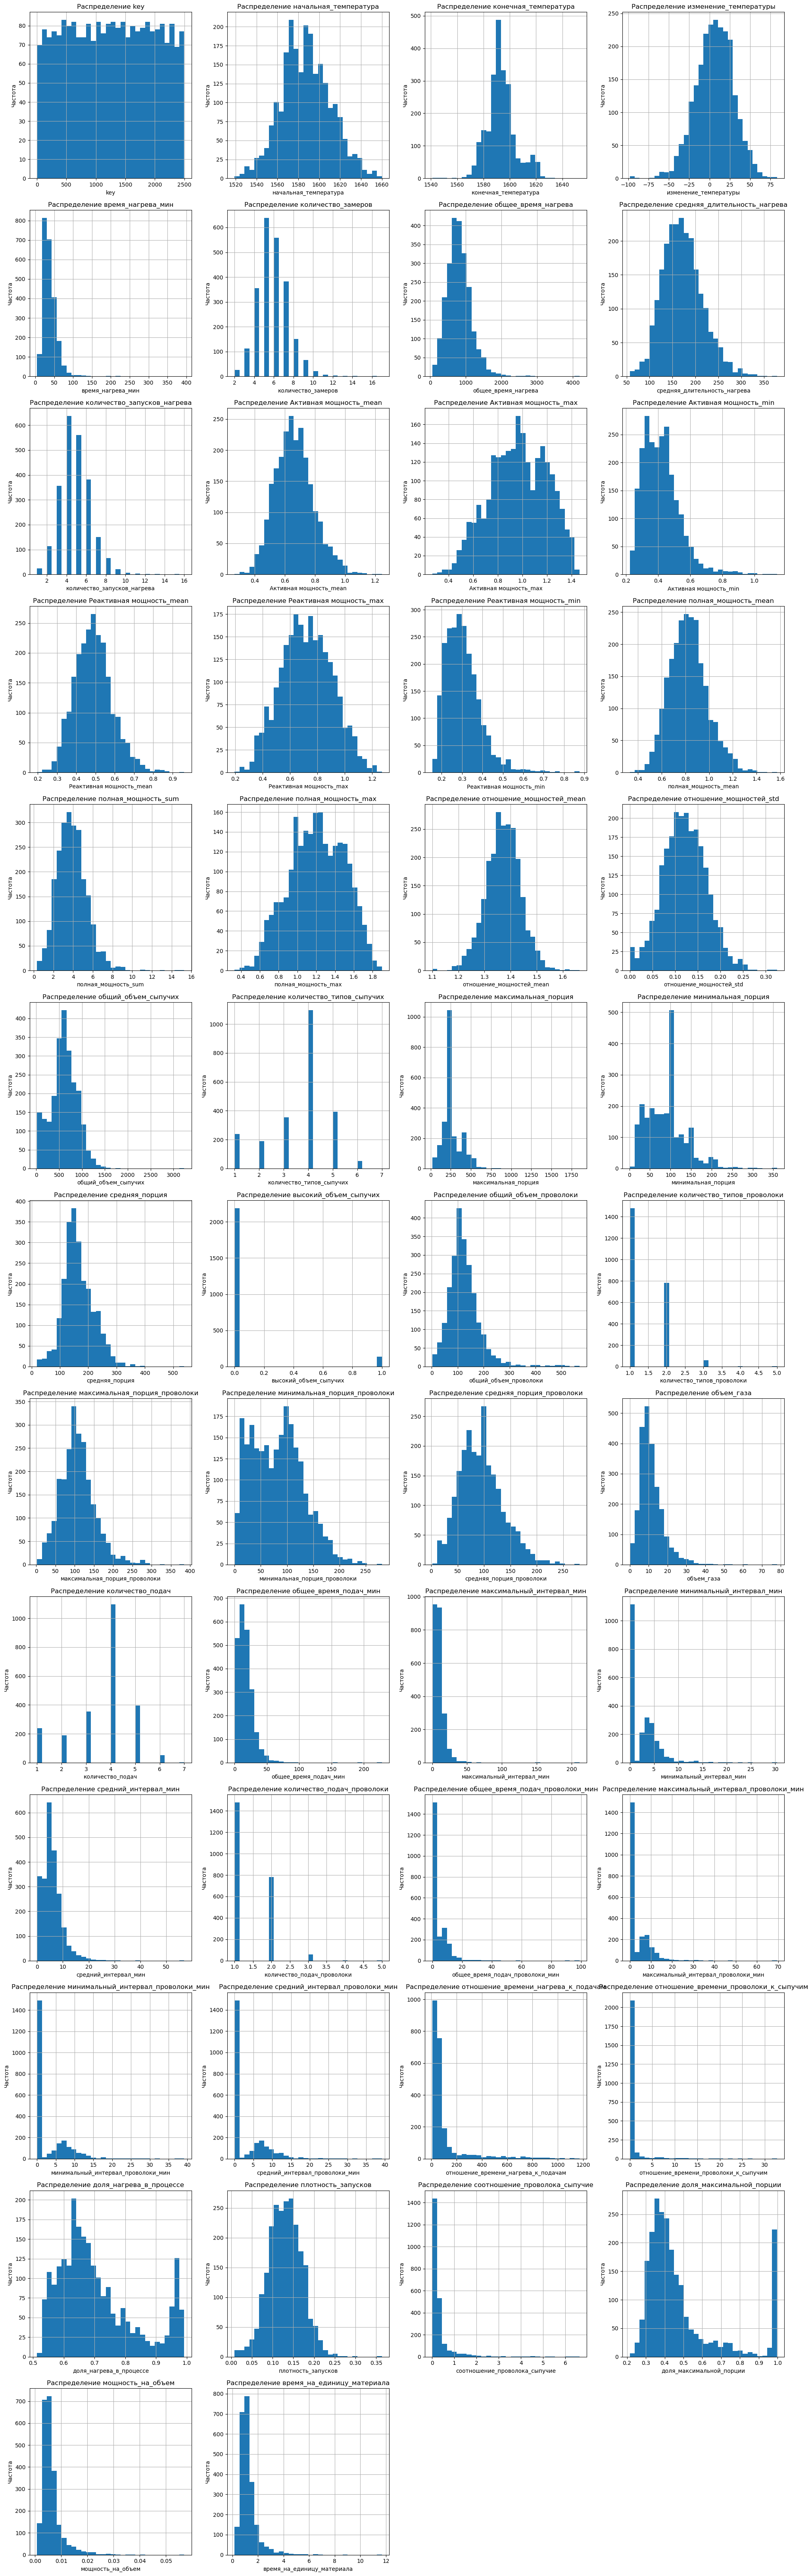

In [51]:
numeric_cols = final_df.select_dtypes(include=[np.number]).columns
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        final_df[col].hist(bins=30, ax=axes[i])
        axes[i].set_title(f'Распределение {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Частота')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Исключая ключ, большинство данных имеют нормальное колокообразное разпределение.

При переводе данных в датафреймы из них были убраны все выбросы (благодаря информации от заказчика) и обработаны все значения.

Однако все еще видны выбивающиеся значения или слишком высокие интервалы во времени. Задач исправить это не стояла и я и сам не знаю, стоит ли их исправлять. Я посмотрю на корреляционный анализ.

Не все признаки важны.

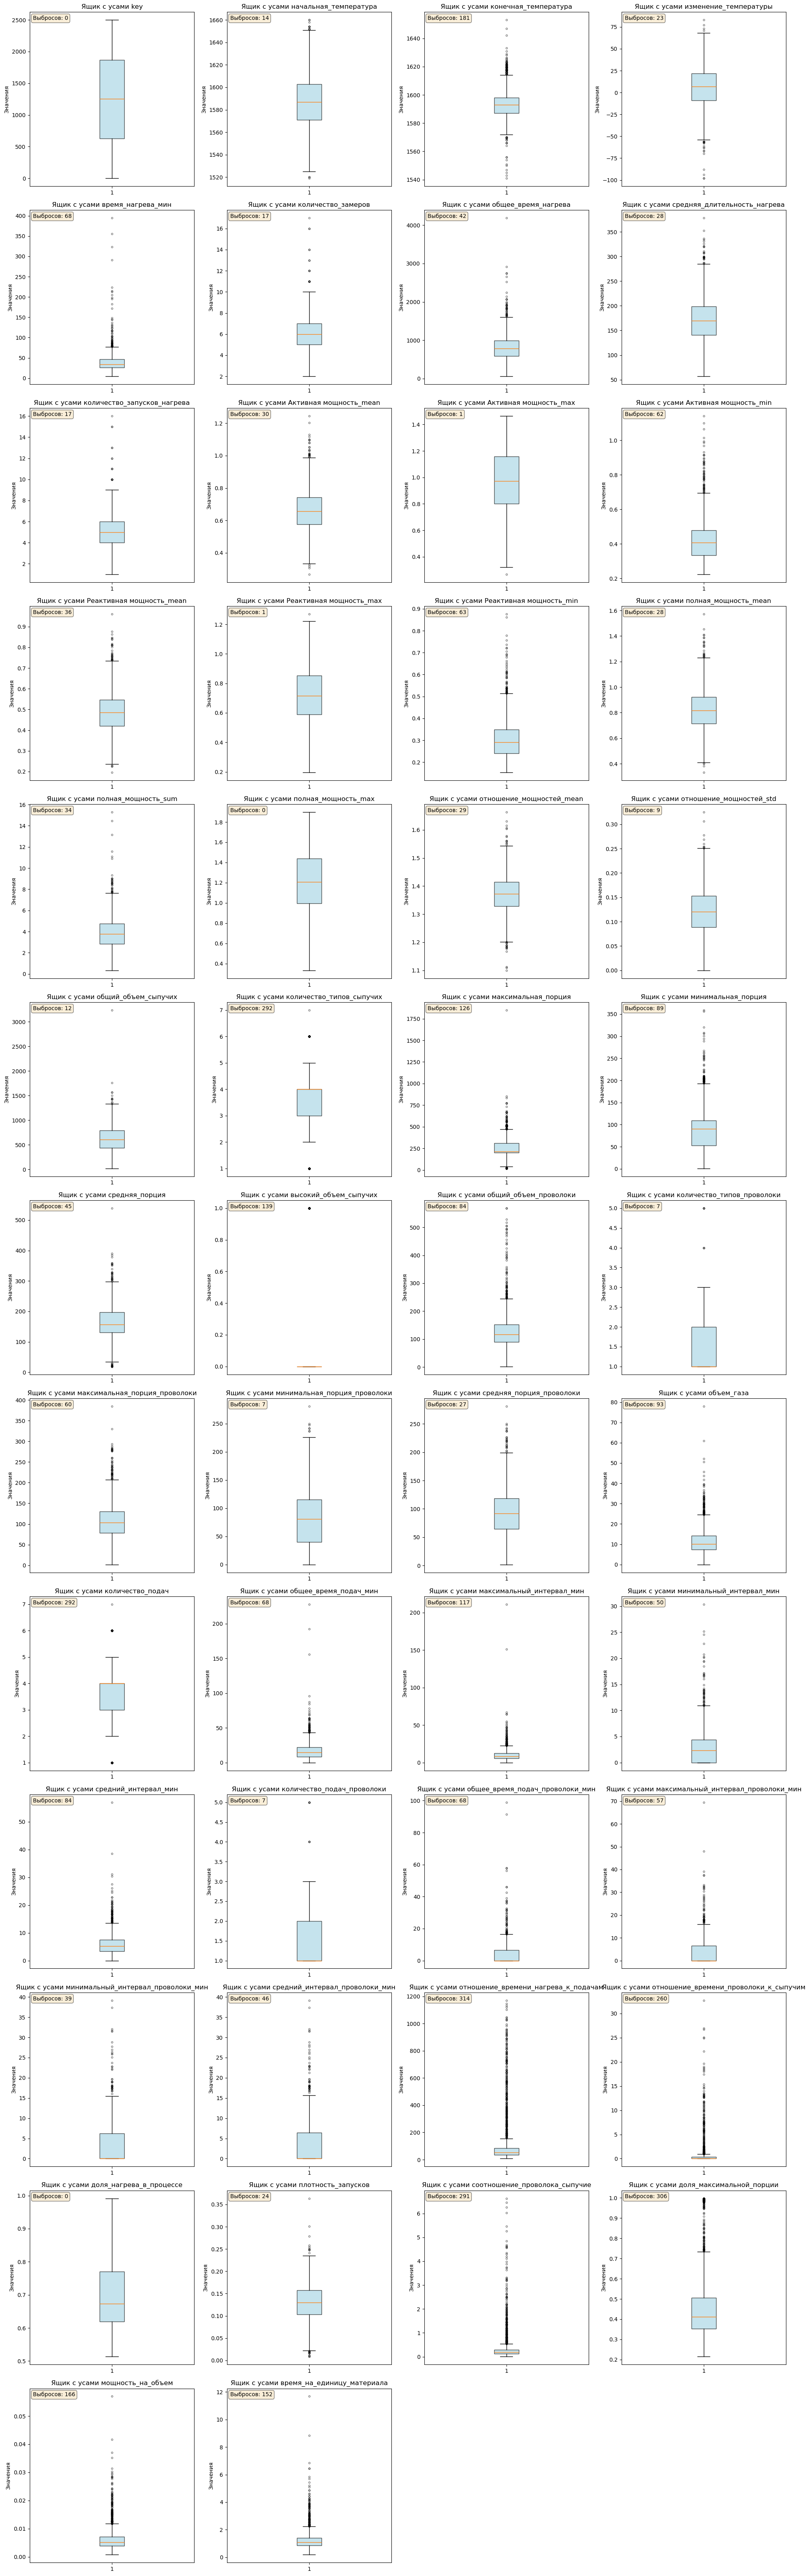

In [52]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        box = axes[i].boxplot(final_df[col], patch_artist=True)
        
        box['boxes'][0].set_facecolor('lightblue')
        box['boxes'][0].set_alpha(0.7)
        box['fliers'][0].set_marker('o')
        box['fliers'][0].set_markersize(3)
        box['fliers'][0].set_alpha(0.5)
        
        axes[i].set_title(f'Ящик с усами {col}')
        axes[i].set_ylabel('Значения')
        
        q1 = final_df[col].quantile(0.25)
        q3 = final_df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers = final_df[(final_df[col] < lower_bound) | (final_df[col] > upper_bound)]
        axes[i].text(0.02, 0.98, f'Выбросов: {len(outliers)}', 
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Почти все имеют выбросы - системная проблема, нарушение стандартов контроля качества или просто человеческий фактор.

Ключ не рассматриваем.

Но я удалять их не буду.

### Проведите корреляционный анализ.


При выводе хетмапа, последний получится слишком обьемным.

target_corr = final_df.corr()['конечная_температура'].sort_values(ascending=False)

In [53]:
target_corr = final_df.corr(method='spearman')['конечная_температура'].sort_values(ascending=False)

Визуализирую

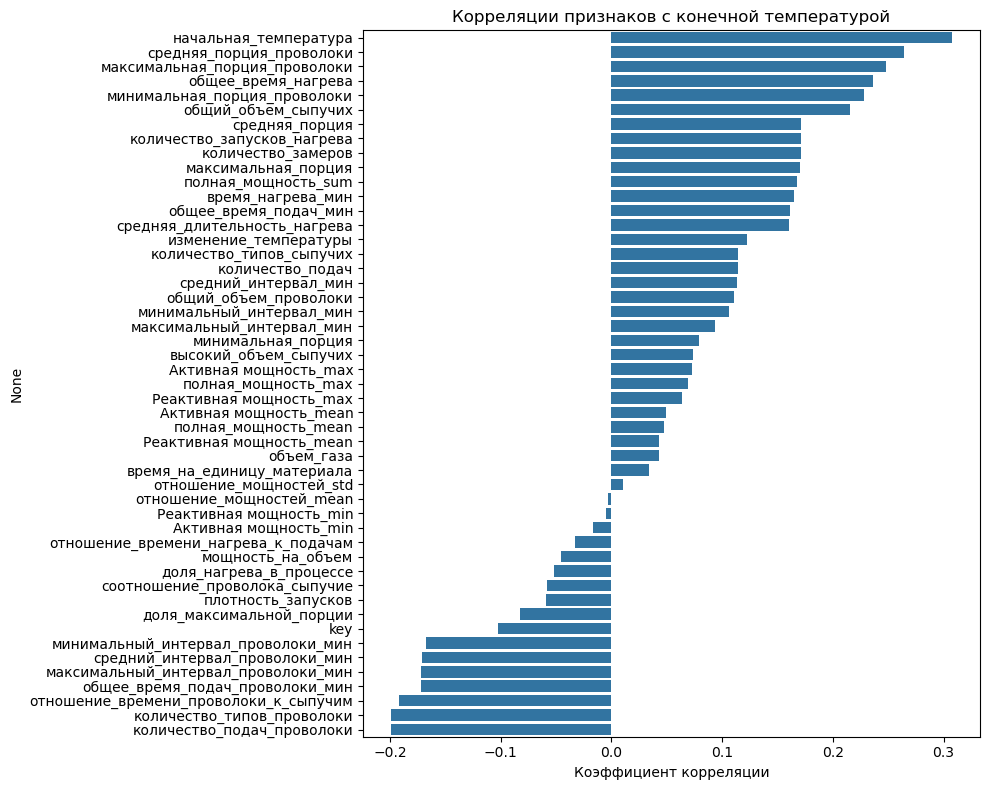

In [54]:
plt.figure(figsize=(10, 8))
target_corr_filtered = target_corr[target_corr.index != 'конечная_температура']
sns.barplot(y=target_corr_filtered.index, x=target_corr_filtered.values)
plt.title('Корреляции признаков с конечной температурой')
plt.xlabel('Коэффициент корреляции')
plt.tight_layout()
plt.show()

А вот теперь, глядя на зто я выведу хетмап с первыми 15-тью и последними 7-ю признаками.

(я не игнорирую признаки с отрицательной корреляцией)

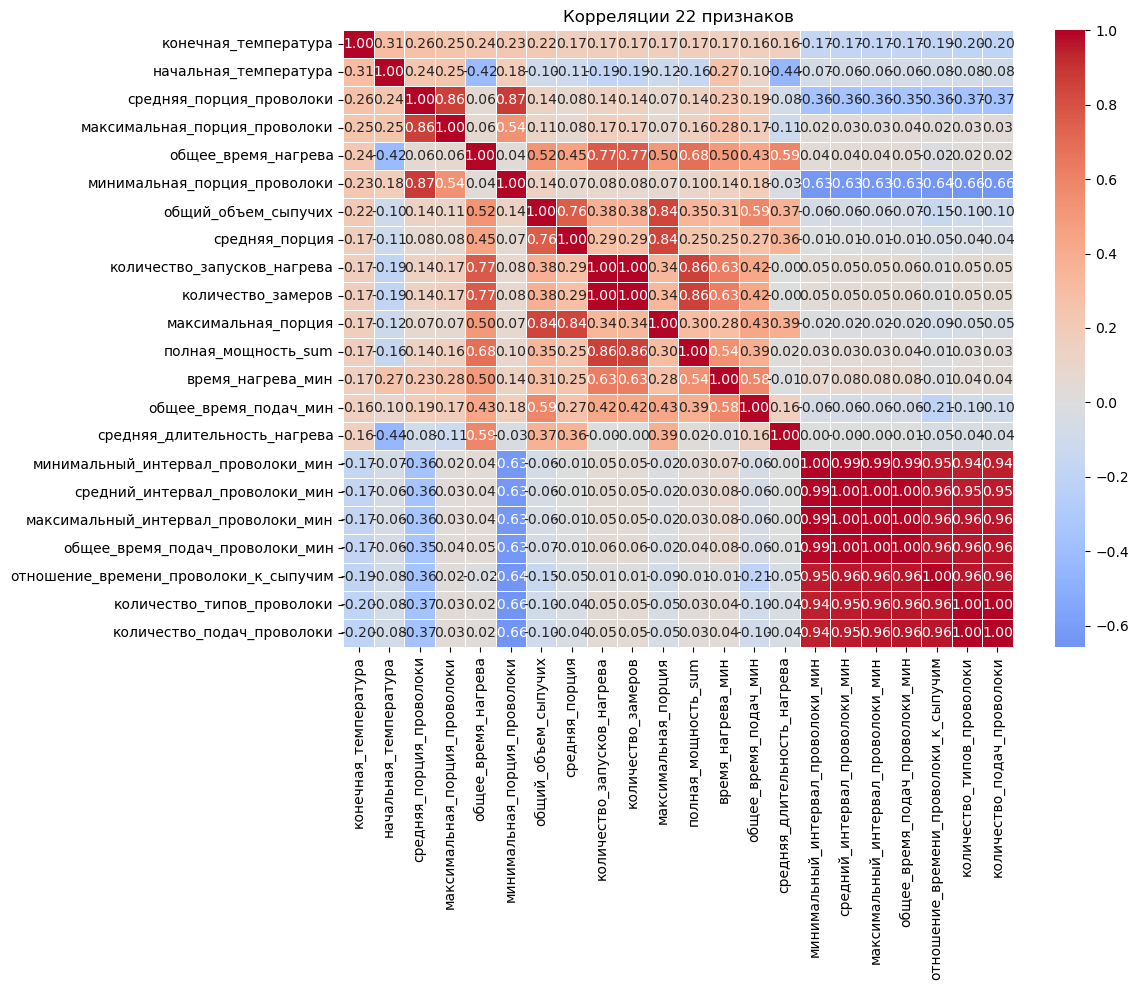

In [55]:
top_features = target_corr.head(15).index.tolist() + target_corr.tail(7).index.tolist()

plt.figure(figsize=(12, 10))
corr_top = final_df[top_features].corr(method='spearman')
sns.heatmap(corr_top, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Корреляции 22 признаков')
plt.tight_layout()
plt.show()

### Подготовьте данные для обучения:
Выберите признаки, которые будете использовать для обучения, учитывайте особенности данных и выбранных моделей.
Разделите данные на тренировочную и тестовую выборки (test_size = 0.25).
Подготовьте выборки для обучения, учитывайте особенности выбранных моделей.

Использую все признаки с |corr| > 0.1.
Да, я просто использую эти признаки.

Пунктом (abs(target_corr) > 0.1) я отрезаю несколько признаков. (Знак модуля сохранает и отрицательные признаки)

In [56]:
target_corr = final_df.corr()['конечная_температура']
features = target_corr[(abs(target_corr) > 0.1) & (target_corr.index != 'конечная_температура')].index.tolist()

print(len(features))

24


Вот столько осталось

In [57]:
features

['начальная_температура',
 'изменение_температуры',
 'количество_замеров',
 'общее_время_нагрева',
 'средняя_длительность_нагрева',
 'количество_запусков_нагрева',
 'полная_мощность_sum',
 'общий_объем_сыпучих',
 'количество_типов_сыпучих',
 'максимальная_порция',
 'средняя_порция',
 'количество_типов_проволоки',
 'максимальная_порция_проволоки',
 'минимальная_порция_проволоки',
 'средняя_порция_проволоки',
 'количество_подач',
 'общее_время_подач_мин',
 'количество_подач_проволоки',
 'общее_время_подач_проволоки_мин',
 'максимальный_интервал_проволоки_мин',
 'минимальный_интервал_проволоки_мин',
 'средний_интервал_проволоки_мин',
 'отношение_времени_проволоки_к_сыпучим',
 'доля_максимальной_порции']

#### Бритва Оккама

In [58]:
features_to_remove = [
    # Убираем признаки которые дублируют друг друга
    'количество_замеров',                    #количество_запусков_нагрева
    'количество_подач',                      #количество_типов_сыпучих
    'количество_подач_проволоки',            #количество_типов_проволоки
    
    # Убираем производные и менее информативные
    'изменение_температуры',  
    'полная_мощность_sum',   
    'доля_максимальной_порции',   
    'средняя_порция',   
    'средняя_порция_проволоки',  
    
    # Убираем временные признаки проволоки (их много и они бесполезны из-за зависимости от самих себя)
    'общее_время_подач_проволоки_мин',
    'максимальный_интервал_проволоки_мин', 
    'минимальный_интервал_проволоки_мин',
    'средний_интервал_проволоки_мин',
    'время_нагрева_мин',
    'общий_объем_проволоки'
]

In [59]:
#уникальные признаки
features_clean = [f for f in features if f not in features_to_remove]

#мультиколлинеарность
corr_matrix_clean = final_df[features_clean].corr()

high_corr_pairs_clean = []
for i in range(len(corr_matrix_clean.columns)):
    for j in range(i+1, len(corr_matrix_clean.columns)):
        corr_value = abs(corr_matrix_clean.iloc[i, j])
        if corr_value > 0.8:
            high_corr_pairs_clean.append({
                'признак1': corr_matrix_clean.columns[i],
                'признак2': corr_matrix_clean.columns[j],
                'корреляция': corr_value
            })


features = features_clean

In [60]:
print(len(features))

12


(Так я и исправил это. Признаки на основе температуры убраны чуть выше. Это суть этого этапа)

In [61]:
final_df[features]

,начальная_температура,общее_время_нагрева,средняя_длительность_нагрева,количество_запусков_нагрева,общий_объем_сыпучих,количество_типов_сыпучих,максимальная_порция,количество_типов_проволоки,максимальная_порция_проволоки,минимальная_порция_проволоки,общее_время_подач_мин,отношение_времени_проволоки_к_сыпучим
0,1571.0,1098.0,219.6000,5,553.0,4,206.0,1,60.059998,60.059998,18.083333,0.000000
1,1581.0,811.0,202.7500,4,582.0,4,206.0,1,96.052315,96.052315,16.666667,0.000000
2,1596.0,655.0,131.0000,5,544.0,4,205.0,1,91.160157,91.160157,16.383333,0.000000
3,1601.0,741.0,185.2500,4,595.0,4,207.0,1,89.063515,89.063515,14.633333,0.000000
4,1576.0,869.0,217.2500,4,584.0,4,203.0,2,89.238236,9.114560,3.416667,1.169811
...,...,...,...,...,...,...,...,...,...,...,...,...
2323,1570.0,723.0,180.7500,4,719.0,5,256.0,1,89.150879,89.150879,16.700000,0.000000
2324,1554.0,940.0,156.6667,6,796.0,5,256.0,1,114.179527,114.179527,19.516667,0.000000
2325,1571.0,569.0,189.6667,3,665.0,4,230.0,2,94.086723,9.048000,11.133333,0.467033
2326,1591.0,750.0,150.0000,5,733.0,5,207.0,1,118.110717,118.110717,13.666667,0.000000


(2328) - мой предел

In [62]:
#final_df = final_df.dropna(subset=features + ['конечная_температура']) #на всякий

X = final_df[features]
y = final_df['конечная_температура']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

print("Размер train:", X_train.shape)
print("Размер test:", X_test.shape)
print("Пропуски в train:", X_train.isnull().sum().sum())
print("Пропуски в test:", X_test.isnull().sum().sum())

Размер train: (1746, 12)
Размер test: (582, 12)
Пропуски в train: 0
Пропуски в test: 0


У нас 12 признаков. Не очень хороших, но это все что у нас есть. Компенсируем качество количеством. Ставка на начальную температуру.


Данные были разделены без проблем. Из-за их количества я их масштабирую.

In [64]:
#масштабировагие 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Промежуточный вывод

Пропусков нет.
После я добавил еще несколько признаков и получилось 50.

После операции "бритва Оккама", были убраны малозначимые признаки, слабовлияющие признаки и самодублирующиеся признаки.
В общем осталось 12.

Осталось 2328 партий с 12 признаками.
(25%) было утеряно строк при обьеденении датафреймов по ключу.


Признаки для обучения:
Конечная температура - целевая переменная
И если смотреть исключительно на нее, то все признаки имеют СЛАБУЮ корреляцию с ней.

Максимальная корреляция всего 0.31 (начальная температура)

Корреляция 0.3 считается слабой. А выше тут только она. В отрицательном плане тоже.

Начальная температура влияет на конечную.

Время нагрева и параметры проволоки - вторые по важности

Далее идут сыпучие материалы

И временные параметры подач слабо влияют.

Чем больше типов и подач проволоки - тем ниже температура. 

Это все неутешительные новости.

## Шаг 3. Обучите модель
Рассмотрите классы моделей:
решающее дерево или случайный лес,
бустинги,
нейронные сети.
Найдите лучшую модель для прогноза последней измеренной температуры. Оцените её качество метрикой MAE. Выберите лучшую модель по значению метрики на кросс-валидации.
Подберите значения как минимум двум гиперпараметрам хотя бы для одной модели. Лучше всего использовать методы автоматизированного подбора гиперпараметров: GridSearchCV, RandomizedSearchCV, OptunaSearchCV, Optuna и другие.


In [65]:
#выбор лучшей модели по значению метрики на кросс-валидации:
models = {
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'Neural Network': MLPRegressor(random_state=RANDOM_STATE, max_iter=1000)
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, 
                           scoring='neg_mean_absolute_error', 
                           cv=5, n_jobs=-1)
    mae_scores = -scores
    cv_results[name] = {
        'mean_mae': mae_scores.mean(),
        'std_mae': mae_scores.std()
    }
    print(name, "MAE:", mae_scores.mean(), "±", mae_scores.std())

Decision Tree MAE: 9.183769136307818 ± 0.48801427632381217
Random Forest MAE: 6.6726143757675 ± 0.44542112419078267
XGBoost MAE: 6.983242898435901 ± 0.3373383794411393
LightGBM MAE: 6.6463214515559965 ± 0.33494897636239923
Neural Network MAE: 12.532589658130195 ± 0.0968144838571002


In [66]:
best_models = {}

#### RANDOM FOREST

In [67]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                      param_grid_rf, 
                      scoring='neg_mean_absolute_error',
                      cv=5, n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)
best_models['Random Forest'] = grid_rf.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


In [68]:
print("Лучшие параметры RF:", grid_rf.best_params_)
print("Лучший MAE RF:", grid_rf.best_score_)

Лучшие параметры RF: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Лучший MAE RF: -6.674843889218323


#### XGBOOST

In [69]:
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

random_xgb = RandomizedSearchCV(XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                               param_dist_xgb,
                               n_iter=20,
                               scoring='neg_mean_absolute_error',
                               cv=3, n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
random_xgb.fit(X_train, y_train)
best_models['XGBoost'] = random_xgb.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [70]:
print("Лучшие параметры XGB:", random_xgb.best_params_)
print("Лучший MAE XGB:", random_xgb.best_score_)

Лучшие параметры XGB: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Лучший MAE XGB: -6.636070924389677


#### LIGHTGBM

In [71]:
param_grid_lgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, -1],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [31, 50, 100]
}

grid_lgb = GridSearchCV(LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                       param_grid_lgb,
                       scoring='neg_mean_absolute_error',
                       cv=3, n_jobs=-1, verbose=1)
grid_lgb.fit(X_train, y_train)
best_models['LightGBM'] = grid_lgb.best_estimator_

Fitting 3 folds for each of 108 candidates, totalling 324 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000447 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2131
[LightGBM] [Info] Number of data points in the train set: 1746, number of used features: 12
[LightGBM] [Info] Start training from score 1593.747995
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [72]:
print("Лучшие параметры LGB:", grid_lgb.best_params_)
print("Лучший MAE LGB:", grid_lgb.best_score_)

Лучшие параметры LGB: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
Лучший MAE LGB: -6.590233946424771


Результаты базовых моделей на кросс-валидности:

Decision Tree MAE: 9.18 ± 0.48
Random Forest MAE: 6.67 ± 0.44
XGBoost MAE: 6.90 ± 0.38
LightGBM MAE: 6.64 ± 0.33
Neural Network MAE: 12.53 ± 0.09


XGBoost, Random Forest и LightGBM хороши. MAE чуть-чуть улучшился у XGBoost и LightGBM после кросс-валидации.
Другие не подходят из-за высокого MAE и не рассматривались.

Лучший MAE RF: -6.674843889218323
Лучший MAE XGB: -6.636070924389677
Лучший MAE LGB: -6.590233946424771

(нейронные сети не трогал после кросс-валидации)

## Шаг 4. Протестируйте модель и продемонстрируйте её работу
Проверьте качество лучшей модели на тестовой выборке. Значение метрики MAE должно быть менее 6.8.
Дополнительно можете оценить R².
Сравните результаты лучшей и константной моделей.
Проанализируйте важность основных признаков.
Для одного из важных признаков проведите дополнительное исследование:
Покажите график зависимости входного и целевого признаков.

По результатам кросс-валидации лучшая модель - LightGBM

In [73]:
best_model = grid_lgb.best_estimator_

Знаю важность тестирования ТОЛЬКО лучшей модели. Их так труднее сравнивать, но в этом нет особого смысла. Если эта модель (необьективно) не идеальна, то для заказчика рекомендовано оставить отзыв по этому поводу.

In [74]:
y_pred = best_model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)

print("LightGBM MAE на тесте:", test_mae,"°C")

LightGBM MAE на тесте: 6.506307814729563 °C


Условие выполнено. Точность предсказания температуры: 6.50 Это меньше 6.8.

6.506307814729563  °C

In [75]:
baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))
print("MSE среднее значение:", baseline_mae, "°C")

MSE среднее значение: 7.937868785992925 °C


### R^2

In [76]:
# Оценка R^2
r2 = r2_score(y_test, y_pred)
print("R^2:", r2)

R^2: 0.3792066298683129


### RMSE

In [77]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE модели:", rmse, "°C")

RMSE модели: 8.596099215923395 °C


In [78]:
baseline_rmse = np.sqrt(mean_squared_error(y_test, [y_train.mean()] * len(y_test)))
print("RMSE среднее значение:", baseline_rmse, "°C")

RMSE среднее значение: 11.013258434793766 °C


### дополнительное исследование

In [79]:
feature_importance = pd.DataFrame({'feature': features,'importance': best_model.feature_importances_}).sort_values('importance', ascending=False)

print("Все признаки")
for i, row in feature_importance.iterrows():
    print(row['feature'],"=", row['importance'])

Все признаки
начальная_температура = 327
общее_время_нагрева = 274
средняя_длительность_нагрева = 221
общее_время_подач_мин = 171
максимальная_порция_проволоки = 165
максимальная_порция = 141
общий_объем_сыпучих = 136
минимальная_порция_проволоки = 119
отношение_времени_проволоки_к_сыпучим = 56
количество_типов_проволоки = 47
количество_типов_сыпучих = 29
количество_запусков_нагрева = 26


Первый это начальная температура. Про неё ниже.

Следующие два это - сумма всех длительностей нагревов и "средняя по больнице" длительность нагрева.

Почему количество_типов_проволоки так сильно может влиять на конечную температуру? С физической точки зрения это легирование.
Видимо мы делаем сталь. Я это отметил еще на первом этапе. На диаграмме железо-углерод видно, как добавка в виде одного лишь углерода влияет на температуру. А тут этих добавок несколько. Там может быть Mn, Si, Cr, Ni и тд.
А может они еще и синергируют друг с другом. Или реакции еще имеют свойство поглощать тепло при реагировании друг с другом. Но это уже химия.
В любом случае это лишь теория. Данных мало.

https://kvadromash.ru/wp-content/uploads/2014/04/Diagramma-zhelezo-uglerod.png

Следующие это минимальные и максимальные порции двух добавок соответственно. Логика есть. Видимо, если бы добавки ТОЖЕ имели начальную температуру или более низкое влияние на плавку, то они бы тут не стояли. А влияют они из-за последующего признака:
Общий объем сыпучих. Это финальный, наиболее влияемый на результат признак. Остальные три несущественны.

Сильно обобщая, первый признак это время нагрева, а второй - величина порций имеет вдвое меньшее влияние.
 
Исследую первые два . Что с ними не так?


#### Первый лучший признак

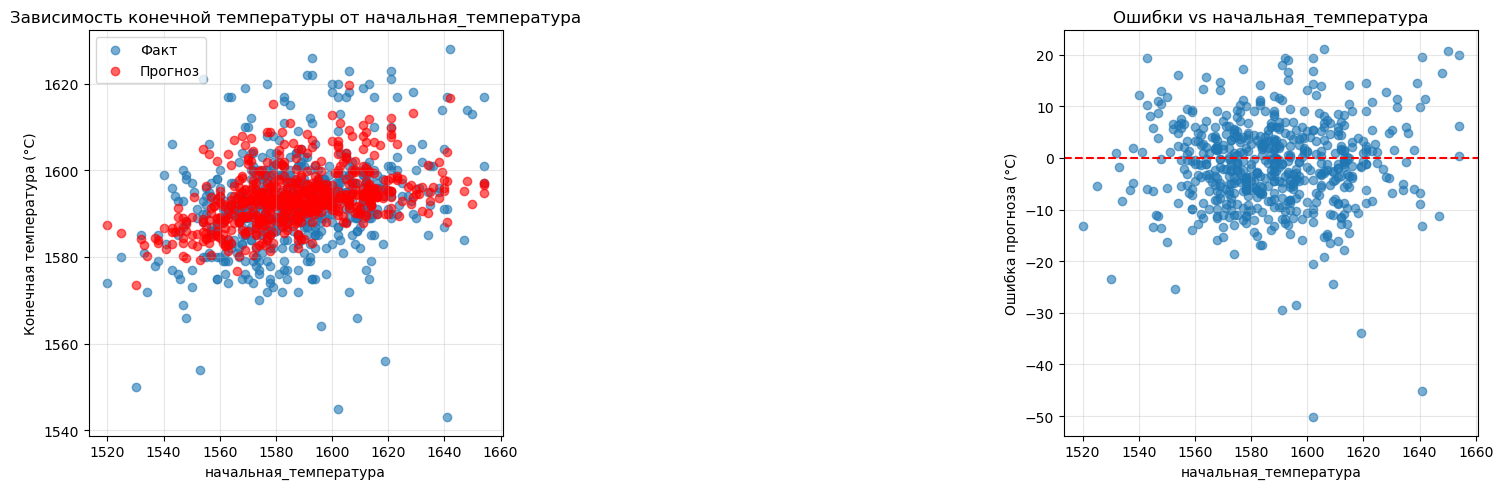

In [80]:
top_feature = feature_importance.iloc[0]['feature']

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_test[top_feature], y_test, alpha=0.6, label='Факт')
plt.scatter(X_test[top_feature], y_pred, alpha=0.6, label='Прогноз', color='red')
plt.xlabel(top_feature)
plt.ylabel('Конечная температура (°C)')
plt.title(f'Зависимость конечной температуры от {top_feature}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
errors = y_test - y_pred
plt.scatter(X_test[top_feature], errors, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel(top_feature)
plt.ylabel('Ошибка прогноза (°C)')
plt.title(f'Ошибки vs {top_feature}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [81]:
print(top_feature, " - статистика признака")
print("Среднее значение:", final_df[top_feature].mean())
print("Стандартное отклонение:", final_df[top_feature].std())
print("Минимальное значение:", final_df[top_feature].min())
print("Максимальное значение:", final_df[top_feature].max())

начальная_температура  - статистика признака
Среднее значение: 1587.3896048109966
Стандартное отклонение: 23.62427597439382
Минимальное значение: 1519.0
Максимальное значение: 1660.0


Сказать особо нечего. Тут все в порядке логики. Так как мы рассматривает только этот этап, я не могу делать выводы о том, какя температура у материала была ИЗНАЧАЛЬНО. Это буквальное "дано". И порекомендовать я тут ничего не могу.

#### Второй лучший признак

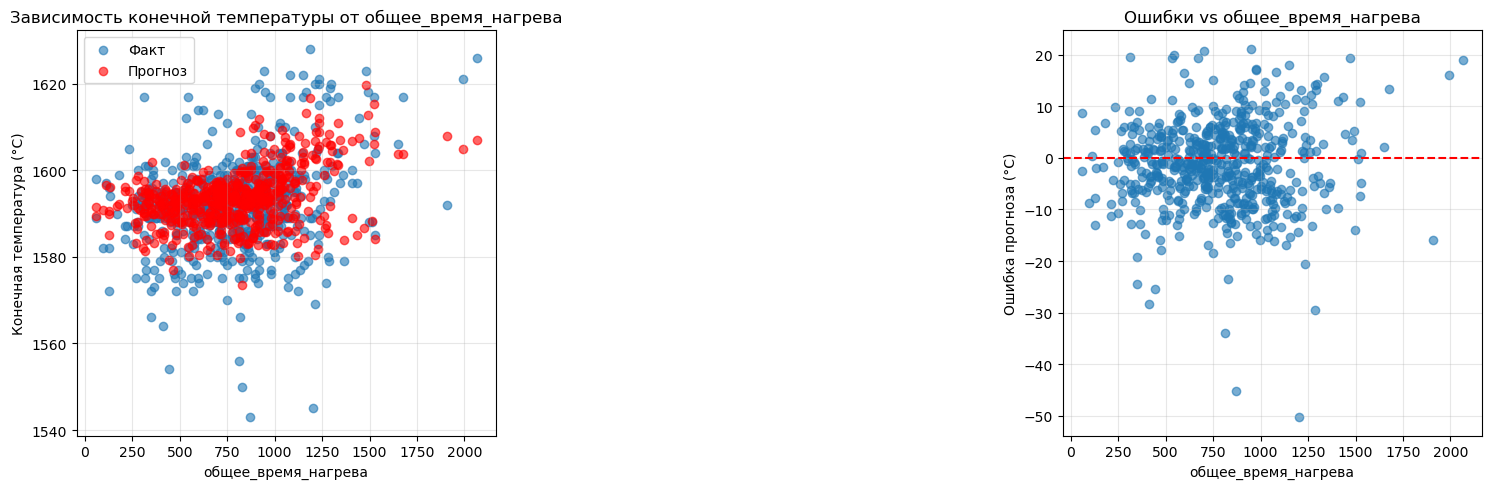

In [82]:
top_feature = feature_importance.iloc[1]['feature']

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_test[top_feature], y_test, alpha=0.6, label='Факт')
plt.scatter(X_test[top_feature], y_pred, alpha=0.6, label='Прогноз', color='red')
plt.xlabel(top_feature)
plt.ylabel('Конечная температура (°C)')
plt.title(f'Зависимость конечной температуры от {top_feature}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
errors = y_test - y_pred
plt.scatter(X_test[top_feature], errors, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel(top_feature)
plt.ylabel('Ошибка прогноза (°C)')
plt.title(f'Ошибки vs {top_feature}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [83]:
print(top_feature, " - статистика признака")
print("Среднее значение:", final_df[top_feature].mean())
print("Стандартное отклонение:", final_df[top_feature].std())
print("Минимальное значение:", final_df[top_feature].min())
print("Максимальное значение:", final_df[top_feature].max())

общее_время_нагрева  - статистика признака
Среднее значение: 807.8084192439862
Стандартное отклонение: 340.82309969193614
Минимальное значение: 57.0
Максимальное значение: 4189.0


Зная на чем основан этот признак, можно сказать что большее число подогревов или пауз увеличивает признак, что коррелирует с ростом температуры из-за дополнительных энерго затрат.

Почему именно два признака проанализированно, а не один? 
Этот топ настолько мало влияет на целевой признак, что рассматривать лишь один- буквально недоговаривать. 
Было решено использовать те, у которых наибольший отрыв от остальных. Да и они схожи по влиянию

1) начальная_температура (32.7%) - исходное состояние стали

2) общее_время_нагрева (27.4%) - интегральный показатель сложности процесса

Оба оптимизировать можно.

### график зависимости входного и целевого признаков.

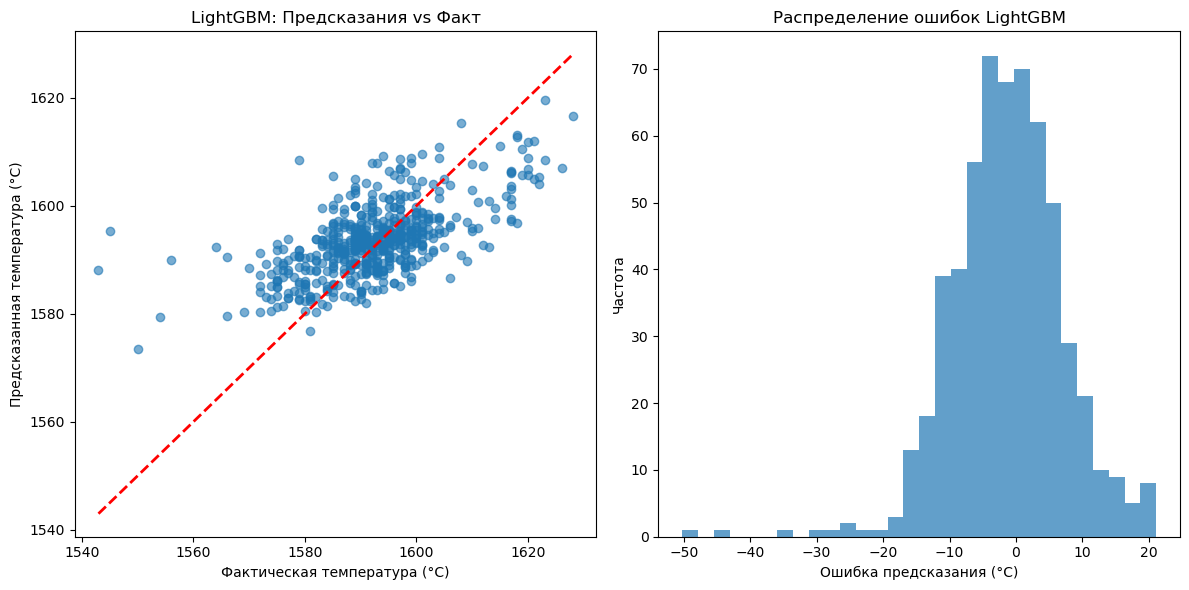

In [84]:
plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.scatter(y_test, best_model.predict(X_test), alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактическая температура (°C)')
plt.ylabel('Предсказанная температура (°C)')
plt.title('LightGBM: Предсказания vs Факт')

# ошибки
plt.subplot(1, 2, 2)
errors = y_test - best_model.predict(X_test)
plt.hist(errors, bins=30, alpha=0.7)
plt.xlabel('Ошибка предсказания (°C)')
plt.ylabel('Частота')
plt.title('Распределение ошибок LightGBM')

plt.tight_layout()
plt.show()

In [85]:
print(f"Стандартное отклонение ошибок: {errors.std():.2f}°C")
print(f"Максимальная ошибка: {errors.abs().max():.2f}°C")

Стандартное отклонение ошибок: 8.50°C
Максимальная ошибка: 50.24°C


Я не знаю как можно (или чем) нивелировать такой диапазон ошибок.
Модель работает - это да. Но это если следовать рекомендациям заказчика. 

Вероятно, есть какое то упущение.

Но зато ошибки нормально распределены от центра графика, а значит ошибки прогнозируемы и я за модель ручаюсь

## Шаг 5. Сделайте общий вывод по работе
Напишите общие выводы, предложите способы для дальнейшего улучшения модели и дайте бизнес-рекомендации заказчику.

И модель прогнозирования конечной температуры в металлургическом процессе была создана. В ход шло все, что у меня и у нас было.
Проект был направлен на оптимизацию технологических параметров с использованием методов машинного обучения для улучшения точности прогнозов, снижения энергозатрат и повышения качества продукции. 


В ходе проекта данные были скачаны. Есть способ подключиться к базе данных, но я скачал.

В ходе исследования пропуски, выбросы были обработаны. Но не все. Этот вопрос стоит рассмотреть отдельно. В любом случае надо присылать данные без аномальных значений, так как не всегда понято что есть что.

Рекомендация: А еще неплохо было бы знать химический состав добавок. Например: хрома было насыпано x, а никеля y.
Это бы улучшило модель очень сильно.

Анализ проведен на основе объединенного датасета из 3120 партий, с применением различных моделей и тщательной подготовкой данных. Признаков было в итоге 50. А использовано было 12 (самых коррелирующихся с основным признаком) Изначально, таких было 50, но большая часть признаков была убрана снова из-за влияния на целевой признак и других причин. То есть признаки отобраны и проверены на мультиколлинеарность

Данные очищены от утечек, аномалий и всего, что могло помешать модели.

Осталось 2328 строк. Эти данные были разделены на выборки

Протестированы 5 классов моделей.
LightGBM показал наилучшие результаты.
Проведен тщательный подбор гиперпараметров (далеко не с первого раза).

Лучшая модель (LightGBM) достигла средней абсолютной ошибки (MAE) в размере 6.50°C на тестовой выборке.

Важные факторы, влияющие на температуру:
1) Начальная температура
2) Время нагрева вообще.
Дополнительно - см.исследование

Не стоит забывать, что некоторые признаки целиком зависят от других. Но несмотря на это, признаки (количество типов проволоки, эффективность нагрева, изменение температуры, начальная температура) очень важны.

Как использовать модель - решать заказчику. Нагрев металла - ОЧЕНЬ энергозатратный процесс. Может он решит добавлять меньше добавок или повысит производительность за счет сокращения циклов нагревания(что бы в нужных моментах тепло не терялось).

Я не знаю как обстоят дела на производстве.


План действий. Глядя на признаки, я рекомендую в заключении следующее:
Cнизить энергоперерасход в виде нескольких минут дополнительного нагрева. Там примерно 5 минут. (см. общее время нагрева)
Нужно назначить норму по времени. У заказчика есть норма по температуре, и такую же надо ввести и по времени. Модель поможет. Её средняя ошибка не выходит за пределы этих пяти минут. Так что это основа для экономии. Этот процесс можно автоматизировать.
Что делать с легирующими материалами- не знаю. Ибо я ограничен в информации про них.(см.выше)

Это сэкономит много денег. Сколько-сказать не могу. Данных нет.